In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from math import pi, sqrt

## Constants

In [2]:
# param
ODE_SOLVE_METHOD = 'RK45'  # 'Radau', 'BDF', 'LSODA', 'RK45', etc.

# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
e_charge = 1.602176634e-19  # Elementary charge, C
hbar = h / (2 * np.pi)    # Reduced Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters of R(56) 32–0 (assumed to be the a10 hyperfine peak) ---
k_a_10 = 18788.348        # cm-1
f_a_10 = k_a_10 * c * 100  # Hz
# f_a_1_to_a_10 = 571e6 # Hz, a1 to a10 hyperfine splitting
print(f"a10 wavelength λ = {c/f_a_10*1e9:.2f} nm")
linewidth = 37e6

# Rb vapor number density (low-pressure) (assumed)
T = 273.15 + 28 # K
L_cell = 5
P_mbar = 0.05 # 10^-1 to 10^-2 mbar
P_Pa = P_mbar * 100 # convert to Pascals
N = P_Pa / (k_B * T)  # ideal gas law, m^-3
print(f"I2 vapor number density N = {N/1e16:.2f} x10^16 m^-3 at T = {T:.2f} K")

D_mode = 31e-6 # m, beam diameter at the PMC

# in power
P_tot = 7e-3
PBS_ratio = 1/9 # 1 : 9 probe to pump power ratio
P_probe = P_tot * 1/(1 + 1/PBS_ratio) / 2 * 0.25 / 2 / 2# /2 for the second PBS, 0.25 for the coupling efficiency to the PMC, /2 again for the PBS before PD1
print(f"Probe to total ratio = 1 : {P_tot/P_probe:.1f}, P_probe = {P_probe*1e3:.2f} mW")

# alpha of iodine
sigma = 3.03e-18 * 1e-4


a10 wavelength λ = 532.24 nm
I2 vapor number density N = 120255.20 x10^16 m^-3 at T = 301.15 K
Probe to total ratio = 1 : 320.0, P_probe = 0.02 mW


## Data unnormalization

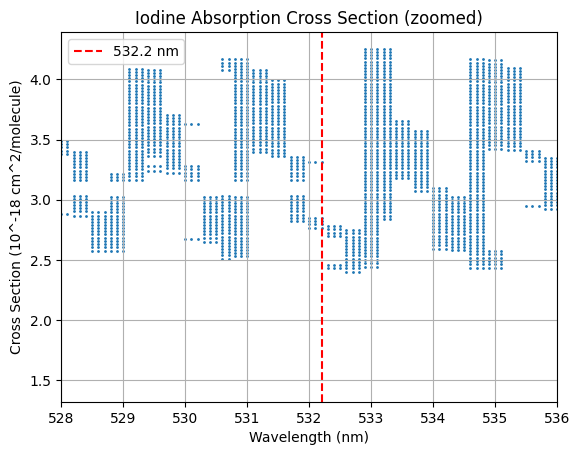

Average cross section around 532.2 nm: 2.91e+00e-18 cm^2/molecule


In [3]:
# graph
filename = "../fig_to_txt/I2 cross section.csv"
data = np.loadtxt(filename, delimiter=',')

plt.figure()
plt.scatter(data[:, 0], data[:, 1], s=1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Cross Section (10^-18 cm^2/molecule)')
plt.title('Iodine Absorption Cross Section (zoomed)')
plt.grid()
plt.xlim(528, 536)
# red vertical line at 532.2 nm
plt.axvline(x=532.2, color='r', linestyle='--', label='532.2 nm')
plt.legend()
plt.show()

# taking the average cross section around 532.2 nm (+- 0.1 nm)
wavelengths = data[:, 0]
cross_sections = data[:, 1]
mask = (wavelengths >= 532.1) & (wavelengths <= 532.3)
avg_cross_section = np.mean(cross_sections[mask]) * 1e-18
print(f"Average cross section around 532.2 nm: {avg_cross_section / 1e-18:.2e}e-18 cm^2/molecule")

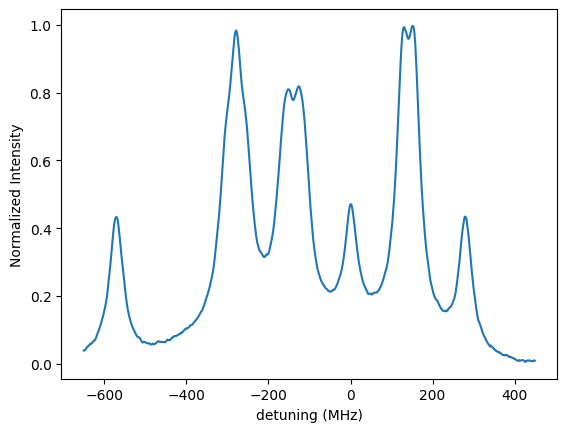

Relative transmission at a10 peak: 0.47
Calculated relative transmission at a10 peak: 0.17
Scaling factor to match calculated transmission: 0.37006457219858424


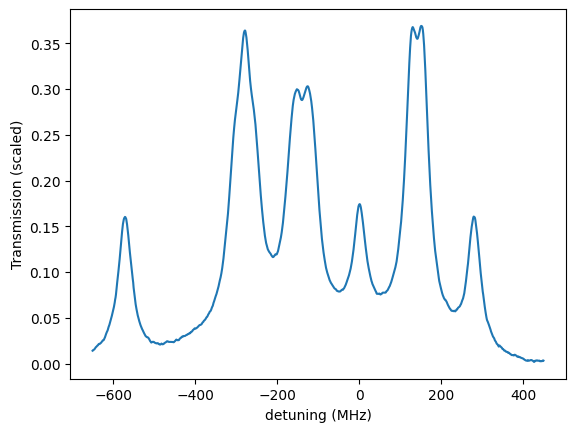

Calculated a1 to a10 hyperfine splitting: 571.00 MHz


In [5]:
filename = "../fig_to_txt/I2 hyperfine.csv"
data = np.loadtxt(filename, delimiter=',')

plt.figure()
plt.plot(data[:, 0], data[:, 1])
plt.xlabel('detuning (MHz)')
plt.ylabel('Normalized Intensity')
plt.show()

# taking the average value closest to 0 detuning (+- 1 MHz)
detuning = data[:, 0]
intensity = data[:, 1]
mask = np.abs(detuning) <= 1 # within +- 1 MHz
T_a10_rel = np.mean(intensity[mask])
print(f"Relative transmission at a10 peak: {T_a10_rel:.2f}")

# transmission from cross section data
alpha = avg_cross_section / 1e4 * N # convert cm^2 to m^2
T_a10_calc = np.exp(-alpha * L_cell)
print(f"Calculated relative transmission at a10 peak: {T_a10_calc:.2f}")

# scale the rest of the graph to match the calculated transmission at a10
scalling_factor = T_a10_calc / T_a10_rel
print(f"Scaling factor to match calculated transmission: {scalling_factor}")
intensity_scaled = intensity * scalling_factor
plt.figure()
plt.plot(detuning, intensity_scaled)
plt.xlabel('detuning (MHz)')
plt.ylabel('Transmission (scaled)')
plt.show()

# calculate a1 peak detuning from a10
mask = (detuning >= -600) & (detuning <= -500) # within -600 to -500 MHz from graph
f_a_1_to_a_10 = np.abs(detuning[np.argmax(intensity_scaled[mask]) + np.where(mask)[0][0]]) * 1e6 # convert MHz to Hz
print(f"Calculated a1 to a10 hyperfine splitting: {f_a_1_to_a_10/1e6:.2f} MHz")

## Ramsey Minimum Quantum Projection Noise

a1 wavelength λ = 532.25 nm
center frequency f0 (THz): 563.2599228679385
linewidth Delta_f (MHz): 37.0
interaction time T_m (ns): 8.602969896859209
number of atoms in interaction volume: 4538236532414.808


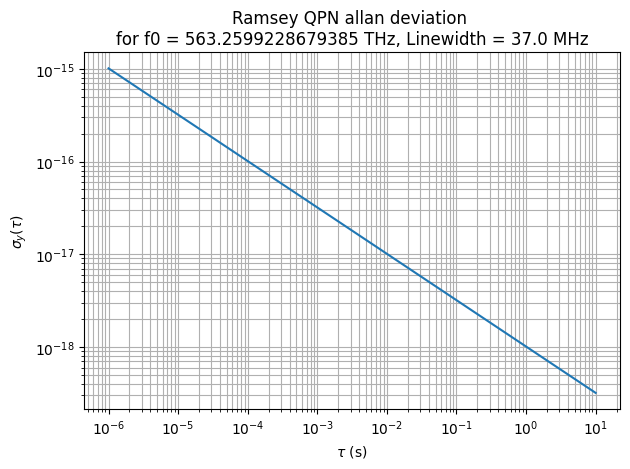

In [14]:
# for testing
f0= f_a_10 - f_a_1_to_a_10 # in Hz
print(f"a1 wavelength λ = {c/f0*1e9:.2f} nm")
Delta_f = linewidth

# Delta_f =38.740e6  # in Hz (example value from fitted Lorentzian widths)
# f0=f_D12 # in Hz
T_m = 1/(2*np.pi*Delta_f / 2) # in seconds
# T_m = 0.5 / (Gamma_D2 / 2 + Gamma_tr_D2)
number = N * np.pi * (D_mode/2)**2 * L_cell   # number of atoms in interaction volume
print("center frequency f0 (THz):", f0/1e12)
print("linewidth Delta_f (MHz):", Delta_f/1e6)
print("interaction time T_m (ns):", T_m * 1e9)
print("number of atoms in interaction volume:", number)

def sigma_y(tau):
    return (1/(2*np.pi*f0)) * np.sqrt(1/(2*number*T_m*tau))

# sigma_y against tau graph in us
# =======================
# Tau range (seconds)
# =======================
tau = np.logspace(-6, 1, 200)  # 1 us to 10 s

# =======================
# Plot
# =======================
plt.figure()
plt.loglog(tau, sigma_y(tau))
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Ramsey QPN allan deviation \nfor f0 = {f0/1e12} THz, Linewidth = {Delta_f/1e6} MHz')
plt.tight_layout()
plt.show()

## Statistical noise
- Intensity-derived noise
    - photon detector noise
    - power supply noise
- Atom number-derived noise
    - quantum projection 
    - gas density
    - photon shot

### Probe intensity-derived noise - PD noise

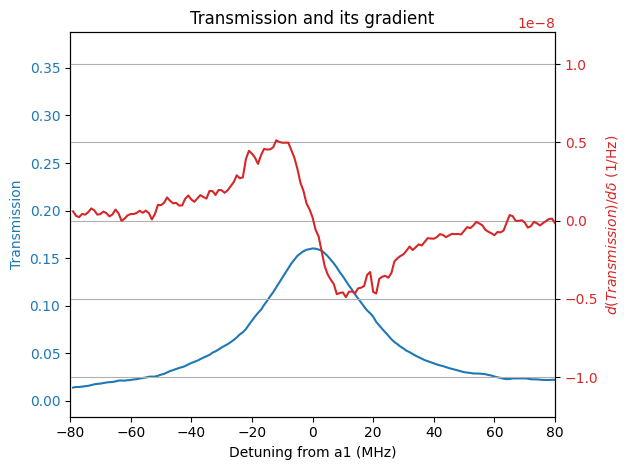

max gradient at detuning 11.00 MHz
min gradient at detuning -12.00 MHz
peak-to-peak gradient distance: 23.00 MHz
modulation frequency 60.00 MHz
bellow is the plot of the error signal generated by modulating the laser at this frequency


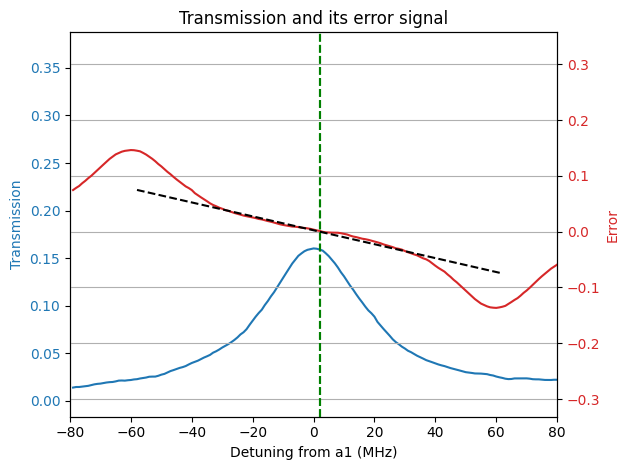

Zero-crossing detuning: 2.00 MHz
center detuning: -0.50 MHz
f0 = 563.259934 THz
dT/dDelta at zero-crossing: -1.25e-09 1/Hz


In [14]:
# Error characterization

delta_array_MHz = detuning
Transm = intensity_scaled

# Transmission with its gradient
dTransm_dDelta = np.gradient(Transm, delta_array_MHz * 1e6)  # convert MHz to Hz for the gradient calculation
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel(r"Detuning from a1 (MHz)")
ax1.set_ylabel(r"Transmission", color=color)
ax1.plot(delta_array_MHz + f_a_1_to_a_10/1e6, Transm, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel(r"$d(Transmission)/d\delta$ (1/Hz)", color=color)  # we already handled the x-label with ax1
ax2.plot(delta_array_MHz + f_a_1_to_a_10/1e6, dTransm_dDelta, color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Transmission and its gradient')
plt.xlim(-80, 80)  # zoom in on the Lamb dip region
plt.grid()
plt.tight_layout()
plt.show()

# finding the point of max gradient and min gradient, and their detuning distance, for delta > 0 (taking the right dip)
delta_mask = delta_array_MHz + 3/5 * f_a_1_to_a_10/1e6 < 0
max_gradient_index = np.argmin(dTransm_dDelta[delta_mask])
min_gradient_index = np.argmax(dTransm_dDelta[delta_mask]) 
print(f"max gradient at detuning {delta_array_MHz[max_gradient_index] + f_a_1_to_a_10/1e6:.2f} MHz")
print(f"min gradient at detuning {delta_array_MHz[min_gradient_index] + f_a_1_to_a_10/1e6:.2f} MHz")
max_gradient_detuning = delta_array_MHz[max_gradient_index] + f_a_1_to_a_10/1e6
min_gradient_detuning = delta_array_MHz[min_gradient_index] + f_a_1_to_a_10/1e6
gradient_distance = max_gradient_detuning - min_gradient_detuning
print(f"peak-to-peak gradient distance: {gradient_distance:.2f} MHz")

# mod_frequency = gradient_distance / 2
mod_frequency = 60 # from paper
print(f"modulation frequency {mod_frequency:.2f} MHz")
print("bellow is the plot of the error signal generated by modulating the laser at this frequency")

# plot the transmission with error signal from the modulation
def Transm_Error(x, delta_array_MHz, Transm, mod=mod_frequency):
    if(x - mod < delta_array_MHz[0]):
        return np.interp(x + mod, delta_array_MHz, Transm) - Transm[0]  # assume the same value for out-of-bounds
    elif(x + mod > delta_array_MHz[-1]):
        return Transm[-1] - np.interp(x - mod, delta_array_MHz, Transm) 
    return np.interp(x + mod, delta_array_MHz, Transm) - np.interp(x - mod, delta_array_MHz, Transm)
Error = []
for x in delta_array_MHz:
    Error.append(Transm_Error(x, delta_array_MHz, Transm, mod=mod_frequency))  # taking the difference between Transm at f+mod_frequency and f-mod_frequency detuning points
Error = np.array(Error)

fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel(r"Detuning from a1 (MHz)")
ax1.set_ylabel(r"Transmission", color=color)
ax1.plot(delta_array_MHz + f_a_1_to_a_10/1e6, Transm, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel(r"Error", color=color)  # we already handled the x-label with ax1
ax2.plot(delta_array_MHz + f_a_1_to_a_10/1e6, Error, color=color)
ax2.tick_params(axis='y', labelcolor=color)
# marking the zero-crossing point of the error signal within the range of grad min and max
error_mask = (delta_array_MHz + f_a_1_to_a_10/1e6 > min_gradient_detuning) & (delta_array_MHz + f_a_1_to_a_10/1e6 < max_gradient_detuning)
zero_crossing_indices = np.where(np.diff(np.sign(Error[error_mask])))[0] + np.where(error_mask)[0][0]  # adjust indices to match the original array
for idx in zero_crossing_indices:
    if min_gradient_detuning < delta_array_MHz[idx] + f_a_1_to_a_10/1e6 < max_gradient_detuning:
        plt.axvline(x=delta_array_MHz[idx] + f_a_1_to_a_10/1e6, color='green', linestyle='--', label='Zero-crossing point')
        break
plt.axvline(x=delta_array_MHz[idx] + f_a_1_to_a_10/1e6, color='green', linestyle='--', label='Zero-crossing point')
# marking the tangent line at the zero-crossing point
tangent_slope = (Error[idx+1] - Error[idx-1]) / ((delta_array_MHz[idx+1] - delta_array_MHz[idx-1]) * 1e6)  # in 1/Hz
tangent_x = np.linspace(delta_array_MHz[idx] - mod_frequency, delta_array_MHz[idx] + mod_frequency, 100)
tangent_y = tangent_slope * 1e6 * (tangent_x - (delta_array_MHz[idx]))
plt.plot(tangent_x + f_a_1_to_a_10/1e6, tangent_y, color='black', linestyle='--', label='Tangent at zero-crossing')
plt.title('Transmission and its error signal')
plt.xlim(-80, 80)  # zoom in on the Lamb dip region
plt.grid()
plt.tight_layout()
plt.show()
f0 = (delta_array_MHz[idx])*1e6 + f_a_10  # convert MHz to Hz
print(f"Zero-crossing detuning: {delta_array_MHz[idx] + f_a_1_to_a_10/1e6:.2f} MHz")
print(f"center detuning: {(max_gradient_detuning + min_gradient_detuning)/2:.2f} MHz")
print(f"f0 = {f0/1e12:f} THz")
print(f"dT/dDelta at zero-crossing: {tangent_slope:.2e} 1/Hz")


Detection bandwidth: 10000.00 Hz


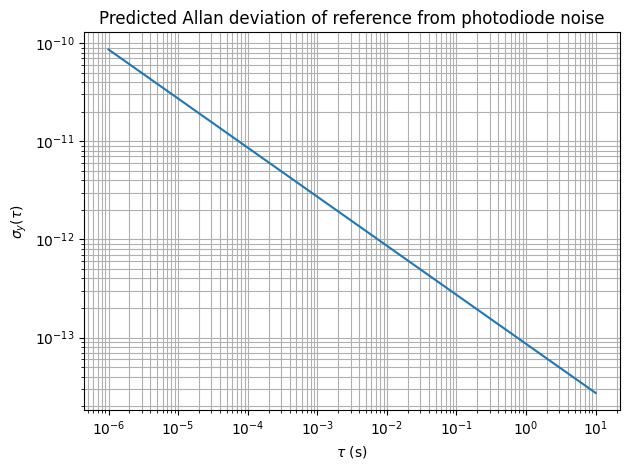

uncertainty f in 100 ms: 0.1033253039958329 kHz Normalized: 2.739909407969641e-13
ref uncertainty in 100 ms: 496 kHz Normalized: 1.3152587157234497e-09


In [23]:
# noise prediction
NEP = 3.1e-15   # from S5972 datasheet, in W/Hz^0.5, source https://octopart.com/datasheet/hamamatsu-photonics/S5972
# R_f = 50
# C_tot = 3e-12 # F, estimated total capaccitance if we only consider the photodetector capacitance 
# bandwidth = 1 / (2 * pi * R_f * C_tot)  # in Hz, where R_f and C_tot are the feedback resistor and total capacitance in the photodetector circuit
bandwidth = 10e3 # in Hz, assuming a detection bandwidth of 10 kHz for the error signal (this is a typical value for laser locking feedback loops using servo)
print(f"Detection bandwidth: {bandwidth:.2f} Hz")

I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pr_W = I_pr_Wm2 * np.pi * (D_D1/2)**2  # in W, where D_D1 is the probe beam diameter in meters
I_pu_Wm2 = 6.2e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2
I_pu_W = I_pu_Wm2 * np.pi * (D_D2/2)**2  # in W, where D_D2 is the pump beam diameter in meters
P_noise = NEP * np.sqrt(bandwidth * np.sqrt(2))  # detected intensity noise in 1 s, in W, where bandwidth is the detection bandwidth in Hz
A_noise = P_noise / I_pr_W  # normalized intensity noise in 1 s

tau = np.logspace(-6, 1, 200)  # 1 us to 10 s
sigma_y_f_int = 1/tangent_slope / f0 * A_noise / np.sqrt(2 * tau)  # fractional frequency instability due to intensity noise, where tangent_slope is the slope of the error signal at the locking point in 1/Hz, f0 is the optical frequency in Hz, A_noise is the normalized intensity noise in 1 s, and tau is the averaging time in seconds
# note: the factor of 2 in the denominator is because the allan deviation already include two variances from the two samples used in the difference calculation, so we need to divide by 2 to get the variance of each sample (assuming NEP is PSD under the common definition)
# ref: https://en.wikipedia.org/wiki/Noise-equivalent_power

plt.figure()
plt.loglog(tau, sigma_y_f_int, label='Predicted Allan deviation from photodiode noise')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation of reference from photodiode noise')
plt.tight_layout()
plt.show()

print("uncertainty f in 100 ms:", f0 * sigma_y_f_int[np.argmin(np.abs(tau - 0.1))] / 1e3, "kHz", "Normalized:", sigma_y_f_int[np.argmin(np.abs(tau - 0.1))])
print("ref uncertainty in 100 ms:", 496, "kHz", "Normalized:", 496e3/f0)

Detection bandwidth: 10000.00 Hz


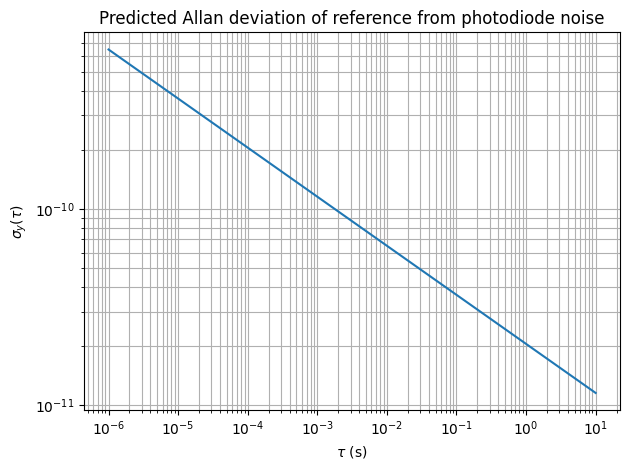

uncertainty f in 100 ms: 13.816175155232036 kHz Normalized: 3.66367838525821e-11
ref uncertainty in 100 ms: 496 kHz Normalized: 1.3152587157234497e-09


In [24]:
# noise prediction
NEP = 3.1e-15   # from S5972 datasheet, in W/Hz^0.5, source https://octopart.com/datasheet/hamamatsu-photonics/S5972
# R_f = 50
# C_tot = 3e-12 # F, estimated total capaccitance if we only consider the photodetector capacitance 
# bandwidth = 1 / (2 * pi * R_f * C_tot)  # in Hz, where R_f and C_tot are the feedback resistor and total capacitance in the photodetector circuit
bandwidth = 10e3 # in Hz, assuming a detection bandwidth of 10 kHz for the error signal (this is a typical value for laser locking feedback loops using servo)
print(f"Detection bandwidth: {bandwidth:.2f} Hz")

I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pr_W = I_pr_Wm2 * np.pi * (D_D1/2)**2  # in W, where D_D1 is the probe beam diameter in meters
I_pu_Wm2 = 6.2e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2
I_pu_W = I_pu_Wm2 * np.pi * (D_D2/2)**2  # in W, where D_D2 is the pump beam diameter in meters
P_noise = np.sqrt(NEP * I_pr_W * np.sqrt(2) / np.sqrt(2 * tau))
A_noise = P_noise / I_pr_W  # normalized intensity noise in 1 s

tau = np.logspace(-6, 1, 200)  # 1 us to 10 s
sigma_y_f_int = 1/tangent_slope / f0 * A_noise 
# note: the factor of 2 in the denominator is because the allan deviation already include two variances from the two samples used in the difference calculation, so we need to divide by 2 to get the variance of each sample (assuming NEP is PSD under the common definition)
# ref: https://en.wikipedia.org/wiki/Noise-equivalent_power

plt.figure()
plt.loglog(tau, sigma_y_f_int, label='Predicted Allan deviation from photodiode noise')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation of reference from photodiode noise')
plt.tight_layout()
plt.show()

print("uncertainty f in 100 ms:", f0 * sigma_y_f_int[np.argmin(np.abs(tau - 0.1))] / 1e3, "kHz", "Normalized:", sigma_y_f_int[np.argmin(np.abs(tau - 0.1))])
print("ref uncertainty in 100 ms:", 496, "kHz", "Normalized:", 496e3/f0)

### Probe intensity-derived noise - Shot noise

quantum efficiency eta: 0.89
Min transmission: 0.1193, Max transmission: 0.1261, Mean transmission: 0.1227


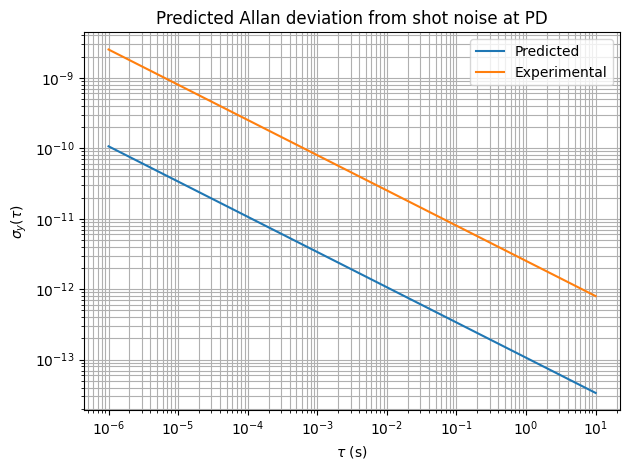

uncertainty f in 1 s: 0.05896181196923423 kHz Normalized: 1.0467957762296364e-13
ref uncertainty in 1 s: 1.3949919844591923 kHz Normalized: 2.4766398257367636e-12


In [15]:
photo_sens = 0.57  # A/W, from S5972 datasheet, at around 800 nm wavelength

Area =  np.pi * (D_mode/2)**2  # in W, where D_mode is the probe beam diameter in meters (asssumed to be the same as the D in PMC)

tau = np.logspace(-6, 1, 200)  # 1 us to 10 s
# eta = h * f0 / e_charge * photo_sens
eta = 0.89 # asssume the same quantum efficiency as the S5972 photodetector 
print(f"quantum efficiency eta: {eta:.2f}")
mean_Transm = (Transm[max_gradient_index] + Transm[min_gradient_index]) / 2
print(f"Min transmission: {Transm[min_gradient_index]:.4f}, Max transmission: {Transm[max_gradient_index]:.4f}, Mean transmission: {mean_Transm:.4f}")
P_det = mean_Transm * P_probe # in W
sigma_I_det = np.sqrt((eta * h * f0 * P_det) / (tau))  
sigma_y_shot = np.sqrt(3) * sigma_I_det / (f0 * P_probe * np.abs(tangent_slope)) 

sigma_y_shot_ref = 2.52e-12 / np.sqrt(tau)  # from the paper, in normalized units
plt.figure()
plt.loglog(tau, sigma_y_shot, label='Predicted')
plt.loglog(tau, sigma_y_shot_ref, label='Experimental')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation from shot noise at PD')
plt.legend()
plt.tight_layout()
plt.show()

print("uncertainty f in 1 s:", f0 * sigma_y_shot[np.argmin(np.abs(tau - 1.0))] / 1e3, "kHz", "Normalized:", sigma_y_shot[np.argmin(np.abs(tau - 1.0))])
print("ref uncertainty in 1 s:", sigma_y_shot_ref[np.argmin(np.abs(tau - 1.0))] * f0 / 1e3, "kHz", "Normalized:", sigma_y_shot_ref[np.argmin(np.abs(tau - 1.0))])

In [18]:
sigma_x = np.sqrt(8.36e-28)
dphi_r_dx = 2 * 2 * pi * f0 / c
I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2

# transmission at 0 detuning
T0 = np.interp(0, delta_array_MHz + f_a_1_to_a_10/1e6, Transm)  # transmission at 0 detuning, from the graph
I_refl = 0.007e-3 / Area
avg_sin_phi = 1/ np.sqrt(2)
dV_dphi_r_k = mean_Transm / np.sqrt(T0) * np.sqrt(I_refl) / I_pr_Wm2 * avg_sin_phi
dT_dx = tangent_slope / 2 / I_pr_Wm2
sigma_y_back_refl = dV_dphi_r_k * dphi_r_dx * sigma_x / f0 / dT_dx

print("uncertainty f in 1 s from back reflection:", f0 * sigma_y_back_refl / 1e3, "kHz", "Normalized:", sigma_y_back_refl)

uncertainty f in 1 s from back reflection: -22.865237184950864 kHz Normalized: -4.059446768729663e-11


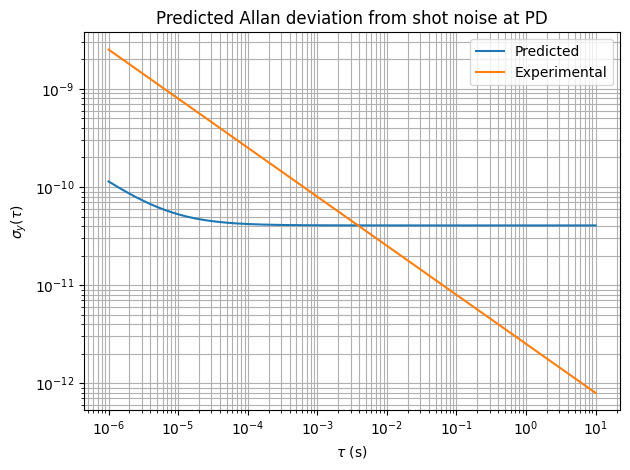

In [19]:
sigma_y_total = np.sqrt(sigma_y_shot**2 + sigma_y_back_refl**2)

plt.figure()
plt.loglog(tau, sigma_y_total, label='Predicted')
plt.loglog(tau, sigma_y_shot_ref, label='Experimental')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation from shot noise at PD')
plt.legend()
plt.tight_layout()
plt.show()

### Atom number-derived noise

In [8]:
# functions

def k_freq_from_lambda(lambda_m):
    return 1.0 / lambda_m

def mb_1d_pdf(v, u):
    """
    1D Maxwell-Boltzmann projection (normalized).
    v : array of velocities (m/s)
    u : most probable speed = sqrt(2 k_B T / m) (m/s)
    returns f_D(v; u)
    """
    return (1.0 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))

def lorentzian_normalized(delta, Gamma_Hz):
    """
    Normalized Lorentzian (area = 1). Use when the formula expects a lineshape g_H(δ,Γ):
    g_H(delta, Gamma) = (1/pi) * ( (Gamma/2) / (delta^2 + (Gamma/2)^2) )
    Input: delta (Hz), Gamma_Hz (Hz)
    Output: s/Hz (integrates to 1 over delta)
    """
    return (1.0 / pi) * ( (Gamma_Hz / 2.0) / (delta**2 + (Gamma_Hz / 2.0)**2) )

def absorption_alpha_from_populations_v2(hbar, omega1j_rad, delta1j_Hz, k_freq, v_array, fD_v, Nj_pop, N1_pop, g_j, g1, Gamma_D1_Hz, B_1j):
    """
    Safer version: k_freq = 1/lambda (cycles/m); delta1j_Hz in Hz.
    Returns alpha (1/m).
    """
    # prefactor ℏ ω / c
    pref = (hbar * omega1j_rad) / c * B_1j

    # lineshape evaluated at (delta1j + k_freq * v) in Hz
    delta_v = delta1j_Hz + k_freq * v_array
    gH_vals = lorentzian_normalized(delta_v, Gamma_D1_Hz)   # units Hz^-1

    # integrand: fD(v) * gH( ... ) * (N1(v) - (g_j/g1) * N_j(v))
    # note: fD_v is omitted here because it's already included in N1_pop and Nj_pop
    integrand = gH_vals * (N1_pop - (g_j / g1) * Nj_pop)

    integral = np.trapz(integrand, v_array)   # integral over v (m/s), output units: (1/m/s) ??? combined pref fixes units
    alpha = pref * integral
    return alpha



# Electronic J values for D1 and D2 transitions
J_ground = 0.5
J_excited_D1 = 0.5   # P1/2
J_excited_D2 = 1.5   # P3/2

# degeneracies used in absorption prefactor
g1 = 2 * 1 + 1   # ground F=1 degeneracy = 3
g2 = 2 * 2 + 1   # ground F=2 degeneracy = 5
g3 = 2 * 1 + 1   # excited D1 F'=1 degeneracy = 3
g4 = 2 * 2 + 1   # excited D1 F'=2 degeneracy = 5
g5 = 2 * 0 + 1   # excited D2 F'=0 degeneracy = 1
g6 = 2 * 1 + 1   # excited D2 F'=1 degeneracy = 3
g7 = 2 * 2 + 1   # excited D2 F'=2 degeneracy =

def Bij_from_C11(omega_ij_rad, J_i, J_j, S_ij, GammaD_angular):
    """
    Compute the Einstein B_ij coefficient using Eq. (C11) form.
    Inputs:
      omega_ij_rad : transition angular frequency ω_ij (rad/s)
      J_i, J_j : total electronic J for initial and final (e.g., 1/2 or 3/2)
      S_ij : dimensionless line-strength factor (from ref; unitless)
      GammaD_angular : natural linewidth (angular) i.e., 2π * (Hz linewidth)
    Returns:
      B_ij in SI (m^3 / J / s) ???  (units consistent with I/c * gH)
    Note:
      Eq. (C11) in the paper shows Bij ∝ (1/3) c^3 π^2 / (ħ ω^3) * (2Jj+1)/(2Ji+1) * S_ij * ΓD.
      We implement that expression literally.
    """
    pref = (1.0/3.0) * (c**3) * (pi**2) / (hbar * (omega_ij_rad**3))
    factor = ((2.0 * J_j + 1.0) / (2.0 * J_i + 1.0))
    B_ij = pref * factor * S_ij * GammaD_angular * S_CONVENTION_CORRECTION
    return B_ij

def build_Bij_for_transitions(transitions_list):
    """
    transitions_list: list of dicts with keys:
       'f'   : transition frequency in Hz (omega/2pi)
       'lambda' : wavelength (m)
       'J_i', 'J_j' : electronic J initial and final
       'S_ij' : line strength factor S_{i->j} (dimensionless)
       'GammaD_Hz' : natural linewidth (Hz) appropriate for that line (D1 or D2)
    Returns: B_ij (float)
    """
    B_map = {}
    for tr in transitions_list:
        omega_rad = 2.0 * pi * tr['f']   # rad/s
        # appendix expects GammaD in angular units inside Bij pref:
        GammaD_angular = 2.0 * pi * tr['GammaD_Hz']
        B_map[tr['label']] = Bij_from_C11(omega_rad, tr['J_i'], tr['J_j'], tr['S_ij'], GammaD_angular)
    return B_map

# Define D1 probe transitions (j=3 and j=4)
transitions_D1 = [
    {'label': '1-3', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_11, 'GammaD_Hz': Gamma_D1},
    {'label': '1-4', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_12, 'GammaD_Hz': Gamma_D1},

    {'label': '3-1', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_11 * (g1/g3), 'GammaD_Hz': Gamma_D1},
    {'label': '4-1', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_12 * (g1/g4), 'GammaD_Hz': Gamma_D1},
]
B_map_D1 = build_Bij_for_transitions(transitions_D1)

def compute_bSAS_alpha_from_final_pop(delta_array_Hz,N1_v, N3_v, N4_v,
                                        v_max_factor=7.0, n_v=20001, verbose=True):
    """
    delta_array_Hz: 1D array of probe detunings (Hz) relative to f_D11 (the reference)
    N_total: total atomic density per m^3 (for the isotope)
    I_pr_Wm2, I_pu_Wm2: intensities
    Returns alpha_vs_detuning (1/m) array same length as delta_array_Hz
    """
    # build velocity grid and MB pdf
    v_max = v_max_factor * u
    v_grid = np.linspace(-v_max, v_max, n_v)
    fD_v = mb_1d_pdf(v_grid, u)  # normalized PDF


    alpha_array = np.zeros_like(delta_array_Hz)

    # precompute k_freq for probe transitions
    k13 = k_freq_from_lambda(lambda_D11)
    k14 = k_freq_from_lambda(lambda_D12)

    # loop over detunings
    for di, delta_hz in enumerate(delta_array_Hz):
        # For monochromatic SAS: pump detuning = probe detuning (scanning same source)
        probe_detuning_Hz = delta_hz

        # Now compute alpha for probe transitions j=3 and j=4 and sum (Eq. C12 summation over j=3,4)
        # prefactor uses ℏ ω1j / c. We'll compute separately and sum.
        omega_13_rad = 2.0 * pi * f_D11
        omega_14_rad = 2.0 * pi * f_D12

        # alpha for j=3
        alpha_13 = absorption_alpha_from_populations_v2(hbar, omega_13_rad, probe_detuning_Hz  - (f_D11 - f_D11),
                                                       k13, v_grid, fD_v, N3_v[di, :], N1_v[di, :],
                                                       g_j=2*1+1, g1=g1, Gamma_D1_Hz=Gamma_D1, B_1j=B_map_D1['1-3'])
        # alpha for j=4
        alpha_14 = absorption_alpha_from_populations_v2(hbar, omega_14_rad, probe_detuning_Hz - (f_D12 - f_D11),
                                                       k14, v_grid, fD_v, N4_v[di, :], N1_v[di, :],
                                                       g_j=2*2+1, g1=g1, Gamma_D1_Hz=Gamma_D1, B_1j=B_map_D1['1-4'])
        alpha_array[di] = alpha_13 + alpha_14

        # (optional) print progress
        if di % max(1, len(delta_array_Hz)//10) == 0 and verbose:
            print(f"bSAS: computed {di+1}/{len(delta_array_Hz)} detunings")

    return alpha_array




In [9]:
def find_delta_p(delta_array_MHz, Error_array, search_min, search_max):
    mask = (delta_array_MHz >= search_min) & (delta_array_MHz <= search_max)
    x = delta_array_MHz[mask]
    y = Error_array[mask]

    # find sign change
    idx = np.where(np.diff(np.sign(y)))[0]
    if len(idx) == 0:
        print("Notice: No zero-crossing found in the specified search range")
        return None

    i = idx[0]
    return np.interp(0, [y[i], y[i+1]], [x[i], x[i+1]])

def compute_error_signal(delta_array_Hz, N1_v, N3_v, N4_v, n_v=20001, verbose=True):
    alpha = compute_bSAS_alpha_from_final_pop(delta_array_Hz, N1_v, N3_v, N4_v, n_v=n_v, verbose=verbose)
    Abs = 1.0 - np.exp(-alpha * L_cell)   # if you already include length; else multiply by cell length L
    delta_array_MHz = delta_array_Hz / 1e6

    Error = np.array([Abs_Error(x, delta_array_MHz, Abs) for x in delta_array_MHz])
    return Abs, Error

def compute_gradient_delta_p(delta_array_Hz, N1_v, N3_v, N4_v,
                             search_min, search_max, eps=1e-5, n_v=20001, verbose=False):

    n_det, n_v = N1_v.shape
    grad = np.zeros(n_v)
    delta_array_MHz = delta_array_Hz / 1e6  # convert to MHz for find_delta_p

    # baseline delta_p
    Abs0, Err0 = compute_error_signal(delta_array_Hz, N1_v, N3_v, N4_v, n_v=n_v, verbose=verbose)
    delta_p0 = find_delta_p(delta_array_MHz, Err0, search_min, search_max)

    for vi in range(n_v):
        # relative perturbation
        dN = eps * np.mean(N1_v[:, vi])
        if dN == 0:
            print(f"Warning: zero population at velocity index {vi}, skipping gradient calculation for this point.")
            continue

        # + perturb
        N1_plus = N1_v.copy()
        N1_plus[:, vi] += dN
        _, Err_plus = compute_error_signal(delta_array_Hz, N1_plus, N3_v, N4_v, n_v=n_v, verbose=verbose)
        delta_p_plus = find_delta_p(delta_array_MHz, Err_plus, search_min, search_max)

        # - perturb
        N1_minus = N1_v.copy()
        N1_minus[:, vi] -= dN
        _, Err_minus = compute_error_signal(delta_array_Hz, N1_minus, N3_v, N4_v, n_v=n_v, verbose=verbose)
        delta_p_minus = find_delta_p(delta_array_MHz, Err_minus, search_min, search_max)

        # gradient
        grad[vi] = (delta_p_plus - delta_p_minus) / (2 * dN)

        if vi+1 % max(1, n_v//10) == 0:
            print(f"v index {vi}/{n_v}, grad={grad[vi]:.3e}")

    return grad, delta_p0

def compute_sigma_N1_QPN(v_grid, N1_v, N_total, Vol, tau_tr, tau):
    fD = mb_1d_pdf(v_grid, u)
    N_vi = N_total * fD
    rho11 = np.mean(N1_v, axis=0) / N_total

    sigma2 = N_vi / Vol * rho11 * (1 - rho11) * tau_tr / tau
    return sigma2

def compute_volume(D, L):
    return np.pi * (D/2)**2 * L

def compute_allan_QPN(f0, grad, sigma2_N1, tau_array):
    sigma2_freq = np.zeros_like(tau_array)

    for ti, tau in enumerate(tau_array):
        sigma2_N1_tau = sigma2_N1(tau)
        sigma2_freq[ti] = np.sum((grad**2) * sigma2_N1_tau)

    allan = np.sqrt(sigma2_freq) / f0
    return allan

In [10]:
# importing population data
filedir = "bSAS_stabil_ref_output"

filename = "alpha.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=1)   # skip header line
delta_array_MHz = np.array(data[:, 0])
delta_array_Hz = delta_array_MHz * 1e6
alpha_array = [np.array(data[:, 1])]

# initial population 
filename = "N1_0.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)   # no header line
N1_0 = np.array(data)

filename = "N2_0.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)   # no header line
N2_0 = np.array(data)

# final population
# lines for detunings while collumns for populations at different velocities
filename = "N1_v.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)   # no header line
N1_v = np.array(data)

filename = "N3_v.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)
N3_v = np.array(data)

filename = "N4_v.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)
N4_v = np.array(data)

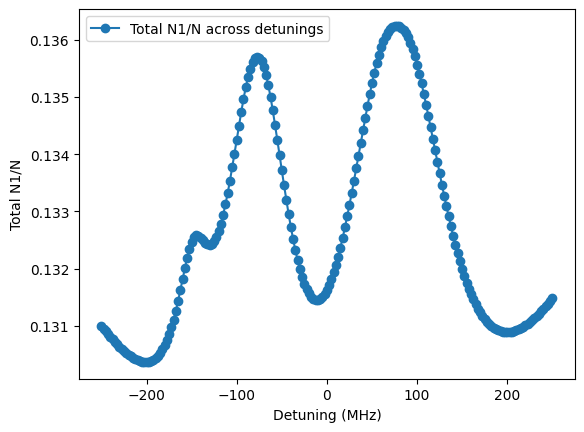

In [11]:
plt.figure()
plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, np.sum(N1_v, axis=1)/N, "o-", label=f"Total N1/N across detunings")
# plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, Err, "o-", label=f"N1(v_res) * {NRatioVal:.2f}")
# plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i], "r", label=f"N1(v_res) * {NRatioVal:.2f}")
# plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i+1], "b", label=f"N1(v_res) * {NRatioVal:.2f}")
plt.xlabel("Detuning (MHz)")
plt.ylabel("Total N1/N")
plt.legend()
plt.show()

searching for delta_p between 879.50 MHz and 902.00 MHz
baseline delta_p0: 892.16 MHz


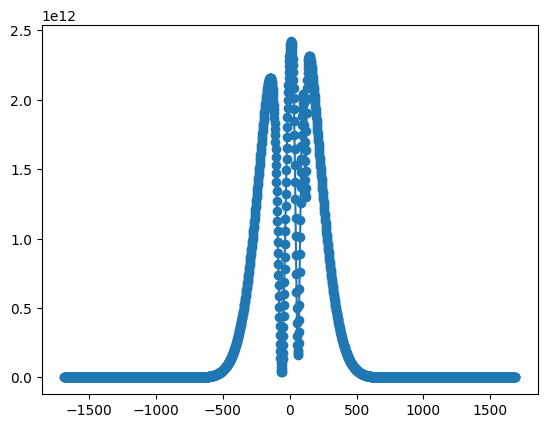

plotting at resonant velocity v0_idx = 964 v_grid[v0_idx] = -60.691600443734615 m/s


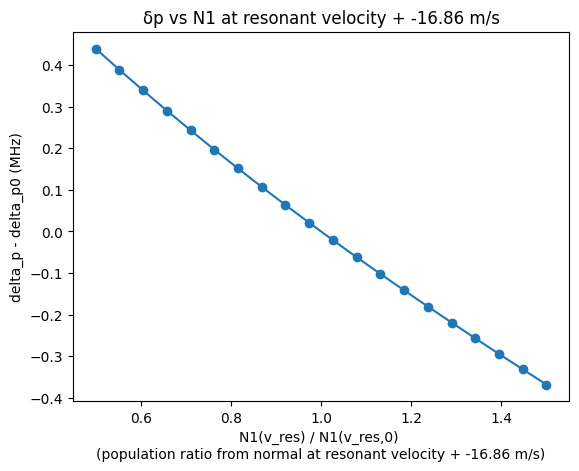

delta_p scan: [ 0.43990594  0.38908005  0.339435    0.29091956  0.24348535  0.19708664
  0.1516802   0.1072251   0.06368258  0.02101588 -0.02080985 -0.06182771
 -0.10206912 -0.14156396 -0.18051121 -0.21902372 -0.257046   -0.29458913
 -0.33166388 -0.36828068]


In [20]:
# plot delta_p vs population at v=resonance to see the sensitivity visually
v_max = 7*u
v_grid = np.linspace(-v_max, v_max, N1_v.shape[1])
delta_min_MHz = min_gradient_detuning + f_p12F1_to_P12F2/1e6
delta_max_MHz = max_gradient_detuning + f_p12F1_to_P12F2/1e6
print(f"searching for delta_p between {delta_min_MHz:.2f} MHz and {delta_max_MHz:.2f} MHz")

Abs0, Err0 = compute_error_signal(delta_array_Hz, N1_v, N3_v, N4_v, n_v=N1_v.shape[1], verbose=False)
delta_p0 = find_delta_p(delta_array_MHz, Err0, delta_min_MHz, delta_max_MHz)
print(f"baseline delta_p0: {delta_p0:.2f} MHz")

p0_idx = np.argmin(np.abs(delta_p0 - delta_array_MHz))
v0_idx = np.argmin(np.abs(N1_v[p0_idx, 850:1000])) + 850
plt.figure()
plt.plot( v_grid, N1_v[p0_idx, :], "o-", label=f"N1(v_res) * {1.0:.2f}")
plt.show()
print("plotting at resonant velocity v0_idx =", v0_idx, "v_grid[v0_idx] =", v_grid[v0_idx], "m/s")

N_ratio_scan = np.linspace(0.5, 1.5, 20) 
# N_ratio_scan = np.array([1.0 - 1e-12, 1.0, 1.0 + 1e-12])  # for testing extreme cases
delta_p_scan = []

i=-10 # shift the fluctuated velocity index by i
for NRatioVal in N_ratio_scan:
    N1_mod = N1_v.copy()
    N1_mod[:, v0_idx+i] *= NRatioVal
    _, Err = compute_error_signal(delta_array_Hz, N1_mod, N3_v, N4_v, n_v=N1_v.shape[1], verbose=False)
    # plt.figure()
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, _, "o-", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, Err, "o-", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i], "r", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i+1], "b", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.show()
    delta_p_scan.append(find_delta_p(delta_array_MHz, Err, delta_min_MHz, delta_max_MHz))

plt.figure()
plt.plot(N_ratio_scan, np.array(delta_p_scan) - delta_p0, 'o-')
plt.xlabel(f"N1(v_res) / N1(v_res,0) \n(population ratio from normal at resonant velocity + {(v_grid[v0_idx+i] - v_grid[v0_idx]):.2f} m/s)")
plt.ylabel("delta_p - delta_p0 (MHz)")
plt.title(f"δp vs N1 at resonant velocity + {(v_grid[v0_idx+i] - v_grid[v0_idx]):.2f} m/s")
plt.show()
# plt.tight_layout()
print("delta_p scan:", np.array(delta_p_scan) - delta_p0)

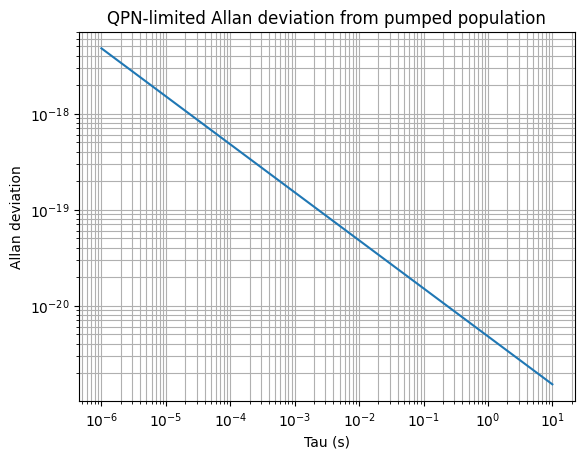

In [ ]:
tau_array = np.logspace(-6, 1, 200)

# velocity grid must match your population grid
v_max = 7*u
v_grid = np.linspace(-v_max, v_max, N1_v.shape[1])
vol = compute_volume(D_D1, L_cell)

delta_min_MHz = min_gradient_detuning + f_p12F1_to_P12F2/1e6
delta_max_MHz = max_gradient_detuning + f_p12F1_to_P12F2/1e6

grad, delta_p0 = compute_gradient_delta_p(delta_array_Hz, N1_v, N3_v, N4_v,
                                          search_min=delta_min_MHz, search_max=delta_max_MHz, n_v=N1_v.shape[1], verbose=False)

def sigma2_func(tau):
    return compute_sigma_N1_QPN(v_grid, N1_v, N, vol, 1/Gamma_tr_D2, tau)

allan = compute_allan_QPN(f0, grad, sigma2_func, tau_array)

plt.figure()
plt.loglog(tau_array, allan)
plt.xlabel("Tau (s)")
plt.ylabel("Allan deviation")
plt.title("QPN-limited Allan deviation from pumped population")
plt.grid(True, which="both")
plt.show()